In [377]:
# This is a more complete version of Effiencies.py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin

# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

In [378]:
# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))
    
    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    #diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time

In [379]:
# import panel data function
def Import_Panel_Data(year, day):
    input_1 = year
    input_2 = day
    # --------REAL PANEL DATA-------------
    #Read the CSV files based on user input
    file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{input_2}.csv",delimiter=',')
    file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{input_2}.csv",delimiter=',')
    
    # Rename the Device ID column to voltage and Voltage to Current
    file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
    file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
    
    # Each file has the data for more than just the day it is. We want to remove these extra dataS
    
    def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
        # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
    
        # You can skip splitting the string and go directly to parsing:
        date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
        
        # 29 # return the day of the year (%j) as an integer
        # The strftime method returns a string, so we convert it to an integer.
        return int(date_object.strftime('%j'))
    # print(f'DEBUG: {input_2}')
    date = file_101['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep =  NumberDate <= int(input_2)
    file_101 = file_101[mask_to_keep]
    # print(f'DEBUG: {mask_to_keep}')
    # print(f'DEBUG: {NumberDate}')
    
    date = file_103['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep = NumberDate <= int(input_2)
    file_103 = file_103[mask_to_keep]
    
    #Extract time, voltage and current data
    
    time_101 = file_101['Time']
    voltage_101 = file_101['V'] 
    current_101 = file_101['A'] 
    
    time_103 = file_103['Time']
    voltage_103 = file_103['V'] 
    current_103 = file_103['A'] 
    
    power_101 = voltage_101 * current_101
    power_103 = voltage_103 * current_103
    # -----------------------------
    return power_101, power_103, time_101, time_103

In [570]:
year = 25
day  = 345

Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
power_101, power_103, time_101, time_103 = Import_Panel_Data(year, day)



https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat


In [571]:
# # plot our data
# fig, ax1 = plt.subplots()
# ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
# ax1.set_ylabel('Power [W]')
# ax1.plot(time_101, power_101, color = 'blue', label = 'Power_101')

# ax2 = ax1.twinx()
# ax2.set_ylabel('Irradiance [W/m**2]')
# ax2.plot(NOAA_time, Direct_Irradiance, color = 'red', label = 'Direct Irradiance', linestyle = '--')
# ax2.plot(NOAA_time, Diffuse_Irradiance, color = 'orange', label = 'Diffuse Irradiance', linestyle = '-')
# ax2.plot(NOAA_time, Upwelling_Irradiance, color = 'black', label = 'Upwelling Irradiance', linestyle = '-.')

# ax1.set_xticks(np.linspace(0, len(time_101), 7))
# ax1.set_title(f'Day {day}')
# plt.show()

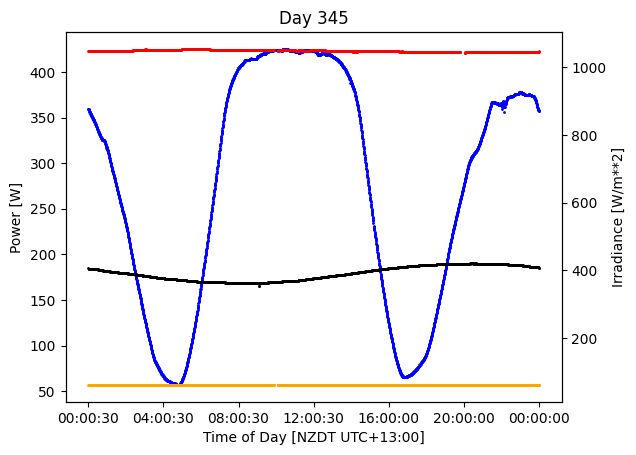

In [572]:
# plot our data
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, color = 'blue', label = 'Power_101', s = 1)

ax2 = ax1.twinx()
ax2.set_ylabel('Irradiance [W/m**2]')
ax2.scatter(NOAA_time, Direct_Irradiance, color = 'red', label = 'Direct Irradiance', s = 1)
ax2.scatter(NOAA_time, Diffuse_Irradiance, color = 'orange', label = 'Diffuse Irradiance', s = 1)
ax2.scatter(NOAA_time, Upwelling_Irradiance, color = 'black', label = 'Upwelling Irradiance', s = 1)

ax1.set_xticks(np.linspace(0, len(time_101), 7))
ax1.set_title(f'Day {day}')
plt.show()

In [573]:
# Make a model for power data using irradiance

# use sigmoids for smooth transition from front to back of panel
def sigmoid(x, sharpness, shift):
    return np.array(1 / (1 + np.exp(-(1/sharpness)*(x + shift))))
 

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness):
    eff_direct = effs[0]
    eff_diffuse = effs[1]
    eff_upwelling = effs[2]
    efficiency_back = .7

    Change_Time_1 = 280
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back

    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_diffuse*Diffuse_Irradiance + eff_upwelling*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power

    

In [574]:
# we want to fit the efficiencies and the sharpness
Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
def Fit_Model(time, eff_dir, eff_diff, eff_upwelling, sharpness):
    '''
    wrapping function for model
    '''
    effs = [eff_dir, eff_diff ,eff_upwelling]
    sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, 50)
    sim_power_2880 = np.repeat(sim_power, 2)
    return sim_power_2880[:-1]


https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat


In [575]:

print(len(power_101))
# Using lmfit to fit
from lmfit import Model
from lmfit import fit_report
mod = Model(Fit_Model)

params = mod.make_params([.22,.01,.07, 45]) # using the diff and upwelling from edges
print(mod.param_names,mod.independent_vars)

params['eff_dir'].set(min=0, max=.3)     
params['eff_diff'].set(min=0, max=.3)
params['eff_upwelling'].set(min=0, max=.3)
params['sharpness'].set(min = 1, max = 100)

DayArrayPowerLength = len(power_101)
x = np.arange(0,DayArrayPowerLength,1)
y = power_101

result = mod.fit(y, params, time=x, method='leastsq', nan_policy = 'omit')

# Print a comprehensive report of the results
# print(result.fit_report())

# Access the best-fit values
# print(f"Best Amplitude: {result.params['eff_dir'].value}")


fitted_dir_eff = result.params['eff_dir'].value
fitted_diff_eff = result.params['eff_diff'].value
fitted_upwelling_eff = result.params['eff_upwelling'].value
fitted_sharpness = result.params['sharpness'].value


print()
print()
# print(f'fitted_dir_eff = {fitted_dir_eff}')
# print(f'fitted_diff_eff = {fitted_diff_eff}')
# print(f'fitted_upwelling_eff = {fitted_upwelling_eff}')
# print(f'fitted_sharpness = {fitted_sharpness}')

print(fit_report(result))

2879
 - Adding parameter "eff_dir"
 - Adding parameter "eff_diff"
 - Adding parameter "eff_upwelling"
 - Adding parameter "sharpness"
['eff_dir', 'eff_diff', 'eff_upwelling', 'sharpness'] ['time']


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 69
    # data points      = 2833
    # variables        = 4
    chi-square         = 1281085.64
    reduced chi-square = 452.840452
    Akaike info crit   = 17329.3216
    Bayesian info crit = 17353.1180
    R-squared          = nan
##  Warning: uncertainties could not be estimated:
    sharpness:      at initial value
    sharpness:      at boundary
[[Variables]]
    eff_dir:        0.22786714 (init = 0)
    eff_diff:       0.29999058 (init = 0)
    eff_upwelling:  0.01836014 (init = 0)
    sharpness:      1.00000000 (init = 1)


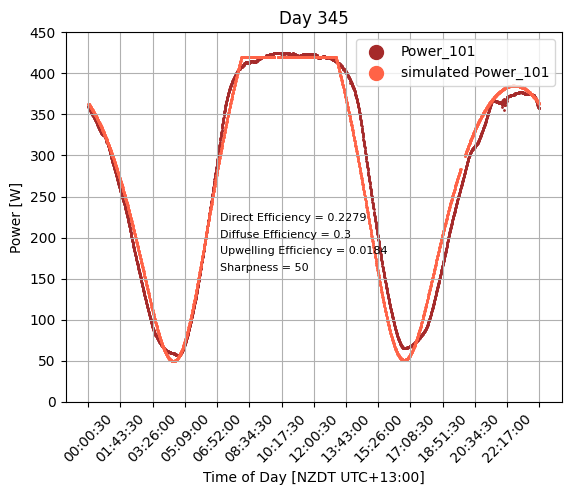

In [576]:
eff_direct = fitted_dir_eff
eff_diffuse = fitted_diff_eff
eff_upwelling = fitted_upwelling_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_diffuse = .01
# eff_upwelling = .07
sharpness = 50

simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_diffuse, eff_upwelling], sharpness),2)[:-1]

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
ax1.text(840,260-40,f'Direct Efficiency = {np.round(eff_direct, 4)}', fontsize = 8)
ax1.text(840,240-40,f'Diffuse Efficiency = {np.round(eff_diffuse, 4)}', fontsize = 8)
ax1.text(840,220-40,f'Upwelling Efficiency = {np.round(eff_upwelling, 4)}', fontsize = 8)
ax1.text(840,200-40,f'Sharpness = {np.round(sharpness, 4)}', fontsize = 8)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()

In [577]:
# 2 component fit + 1 sharpness

# Make a model for power data using irradiance

# use sigmoids for smooth transition from front to back of panel
def sigmoid(x, sharpness, shift):
    return np.array(1 / (1 + np.exp(-(1/sharpness)*(x + shift))))
 

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness):
    eff_direct = effs[0]
    eff_isotropic = effs[1]
    efficiency_back = .7

    Change_Time_1 = 280
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back

    
    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power

# we want to fit the efficiencies and the sharpness
Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
def Fit_Model(time, eff_dir, eff_isotropic, sharpness):
    '''
    wrapping function for model
    '''
    effs = [eff_dir, eff_isotropic]
    sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, 50)
    sim_power_2880 = np.repeat(sim_power, 2)
    # print(sim_power)
    return sim_power_2880[:-1]


print(len(power_101))
# Using lmfit to fit
from lmfit import Model
from lmfit import fit_report
mod = Model(Fit_Model)

params = mod.make_params([.22,.01, 45]) # using the diff and upwelling from edges
print(mod.param_names,mod.independent_vars)

params['eff_dir'].set(min=0, max=1)     
params['eff_isotropic'].set(min=0, max=1)
params['sharpness'].set(min = 0, max = 100)

DayArrayPowerLength = len(power_101)
x = np.arange(0,DayArrayPowerLength,1)
y = power_101

result = mod.fit(y, params, time=x, method='nelder', nan_policy = 'omit')

# Print a comprehensive report of the results
# print(result.fit_report())

# Access the best-fit values
# print(f"Best Amplitude: {result.params['eff_dir'].value}")


fitted_dir_eff = result.params['eff_dir'].value
fitted_isotropic_eff = result.params['eff_isotropic'].value
fitted_sharpness = result.params['sharpness'].value


print()
print()
# print(f'fitted_dir_eff = {fitted_dir_eff}')
# print(f'fitted_isotropic_eff = {fitted_isotropic_eff}')
# print(f'fitted_sharpness = {fitted_sharpness}')

print(fit_report(result))

https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat
2879
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
['eff_dir', 'eff_isotropic', 'sharpness'] ['time']


[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 167
    # data points      = 2833
    # variables        = 3
    chi-square         = 1322941.04
    reduced chi-square = 467.470333
    Akaike info crit   = 17418.4010
    Bayesian info crit = 17436.2483
    R-squared          = nan
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    eff_dir:        0.22728883 (init = 0)
    eff_isotropic:  0.05707937 (init = 0)
    sharp

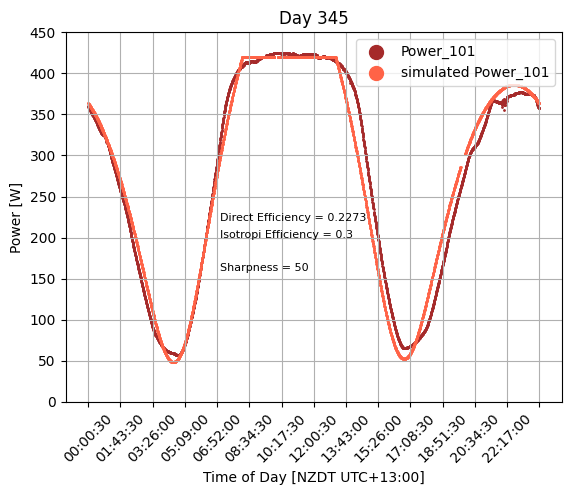

In [578]:
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
sharpness = 50

simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness),2)[:-1]

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
ax1.text(840,260-40,f'Direct Efficiency = {np.round(eff_direct, 4)}', fontsize = 8)
ax1.text(840,240-40,f'Isotropi Efficiency = {np.round(eff_diffuse, 4)}', fontsize = 8)
ax1.text(840,200-40,f'Sharpness = {np.round(sharpness, 4)}', fontsize = 8)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()

In [579]:
# Now let us try not fitting for the efficiencies but calculating them from the extreama of the panel
power_101_numpy = power_101.to_numpy()
# plt.plot(power_101_numpy[500+75+3:500+75+6])
print(f'power_101_numpy[579] = {power_101_numpy[579]}')
print()
isotropic_power = power_101_numpy[579]
# plt.plot(power_101_numpy[2500:-1])
all_comp_power = power_101_numpy[2500+250]
print(f'all_comp_power = {all_comp_power}')
print()
direct_power = all_comp_power - isotropic_power
print(f'direct_power = {direct_power}')
print()
# direct_irradiance is reletivly constant
Direct_Irradiance_instance = Direct_Irradiance[.5*(2500+250)]
print(f'Direct_Irradiance_instance = {Direct_Irradiance_instance}')
print()

Isotropic_Irradiance_instance = Diffuse_Irradiance[.5*(580)] + Upwelling_Irradiance[.5*(580)]
print(f'Isotropic_Irradiance_instance = {Isotropic_Irradiance_instance}')
print()
# power = Irradiance * eff * area
# eff = power / (Irradiance* area)
area = 2
Direct_eff_calc = direct_power / (Direct_Irradiance_instance * area)
print(f'Direct_eff_calc = {Direct_eff_calc}')
print()

Isotropic_eff_calc = isotropic_power / (Isotropic_Irradiance_instance* area)
print(f'Isotropic_eff_calc = {Isotropic_eff_calc}')

power_101_numpy[579] = 56.755255555555564

all_comp_power = 377.5137580246911

direct_power = 320.7585024691356

Direct_Irradiance_instance = 1049.7

Isotropic_Irradiance_instance = 477.6

Direct_eff_calc = 0.1527857971178125

Isotropic_eff_calc = 0.05941714358831194


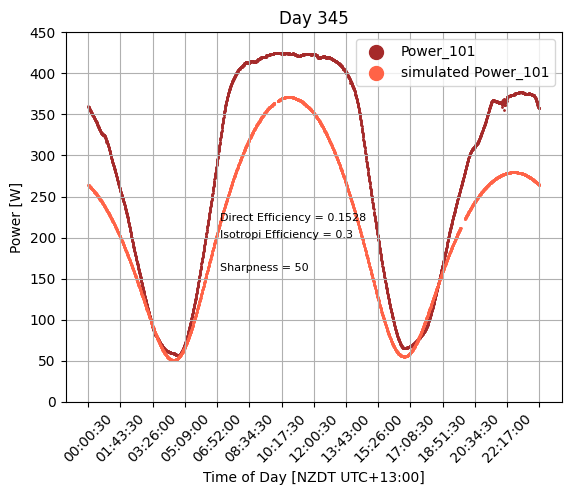

In [580]:
# eff_direct = fitted_dir_eff
# eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

eff_direct = Direct_eff_calc
eff_isotropic = Isotropic_eff_calc
sharpness = 50

simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness),2)[:-1]

fig, ax1 = plt.subplots()
ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
ax1.set_ylabel('Power [W]')
ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
ax1.text(840,260-40,f'Direct Efficiency = {np.round(eff_direct, 4)}', fontsize = 8)
ax1.text(840,240-40,f'Isotropi Efficiency = {np.round(eff_diffuse, 4)}', fontsize = 8)
ax1.text(840,200-40,f'Sharpness = {np.round(sharpness, 4)}', fontsize = 8)
ax1.legend(markerscale = 10)
ax1.set_ylim(0,450)
ax1.set_xticks(np.linspace(0, len(time_101), 15))
ax1.set_title(f'Day {day}')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid('on')
plt.show()

In [581]:
# Lets simulate mutliple panels with different angles with this model

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness, angle_negative):
    '''
    This model function is like the old one but lets you put in the angle of the solar panel
    '''
    eff_direct = effs[0]
    eff_isotropic = effs[1]
    efficiency_back = .7

    # The angle the math uses to calculate is not the angle which makes sens for us to define our panel angle as so I correct for it as such
    angle = 360 - angle_negative
    Change_Time_1 = angle/360*1440
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Tertiary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1-2*Change_Time_1+2*Change_Time_2)*sigmoid(-time, sharpness, Change_Time_2-(-2*Change_Time_1+2*Change_Time_2))
    Tertiary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2+4*Change_Time_2-4*Change_Time_1)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1-(+4*Change_Time_2-4*Change_Time_1))
    # Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back + Tertiary_Back + Tertiary_Front
    
    
    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power



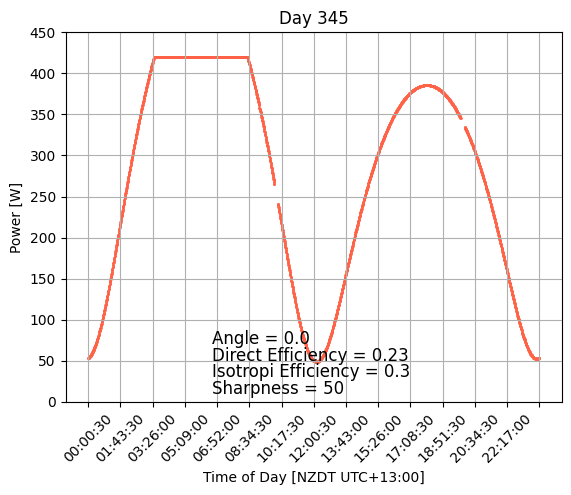

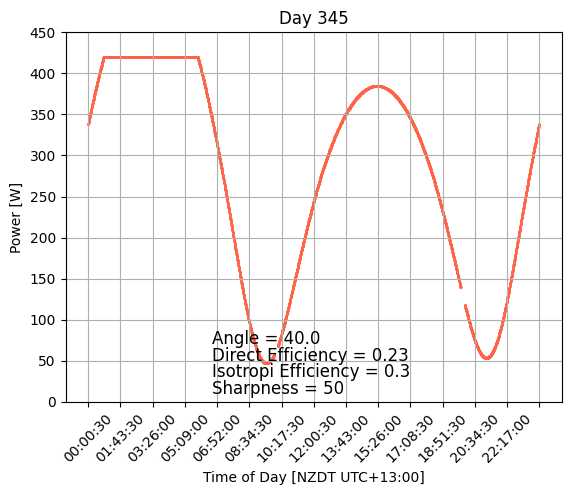

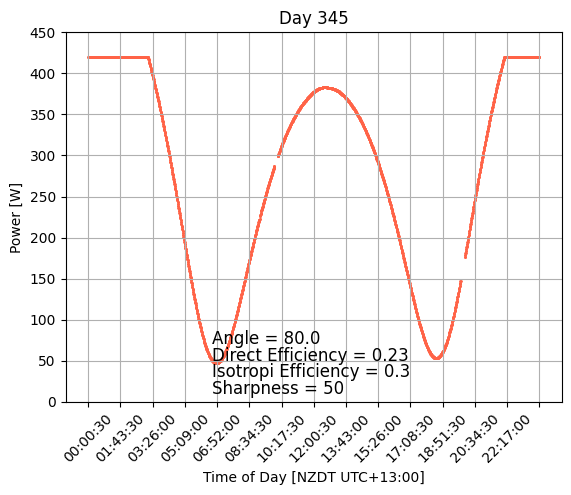

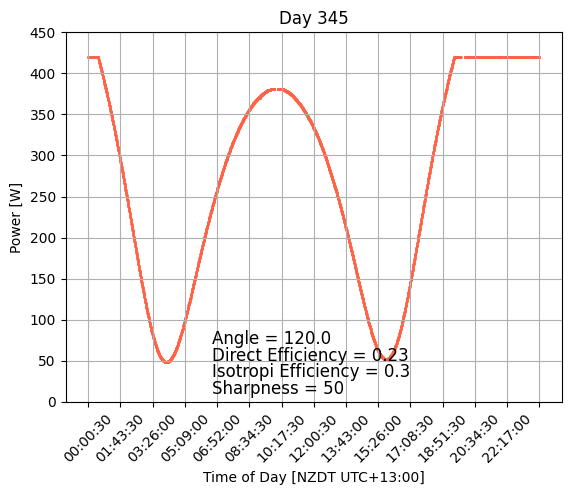

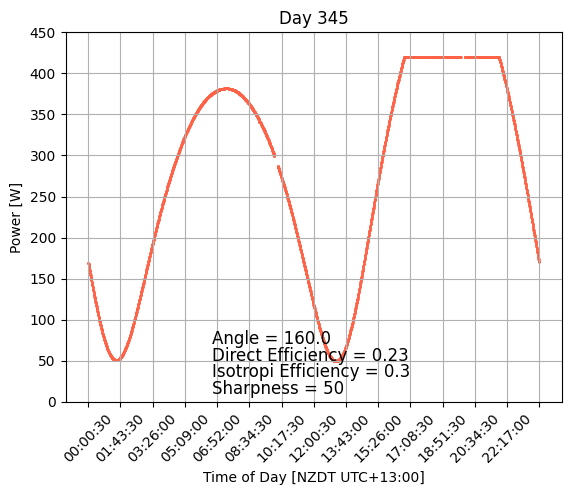

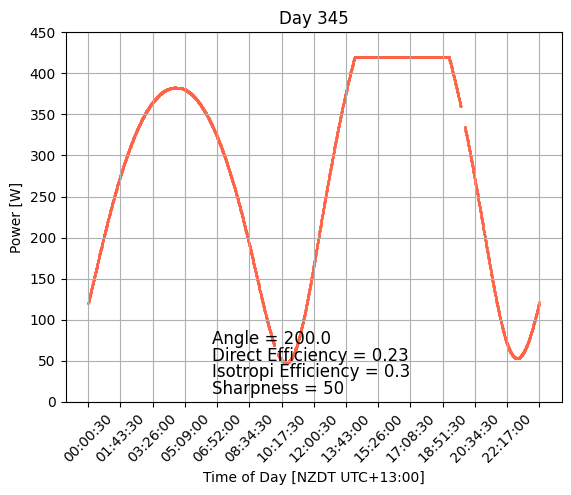

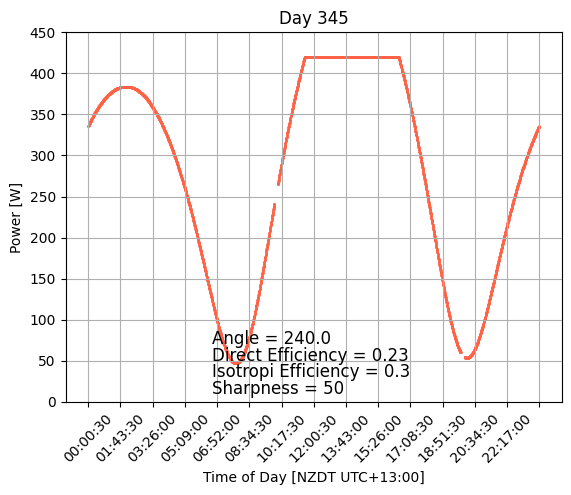

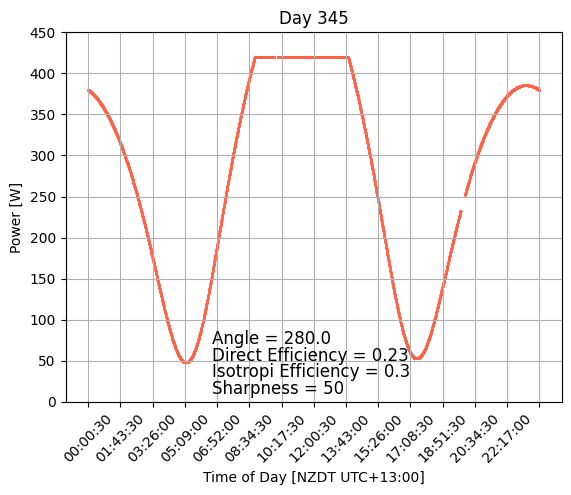

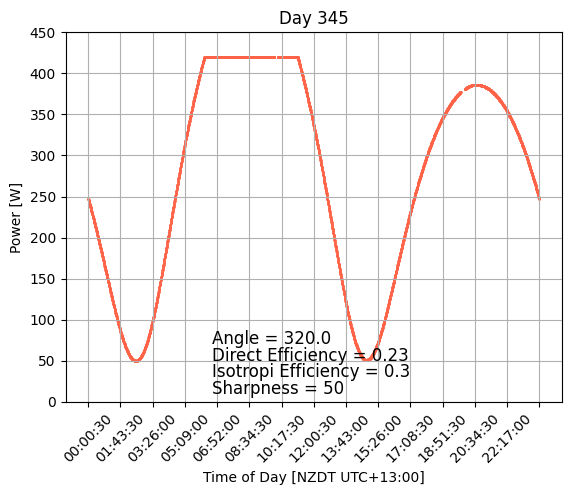

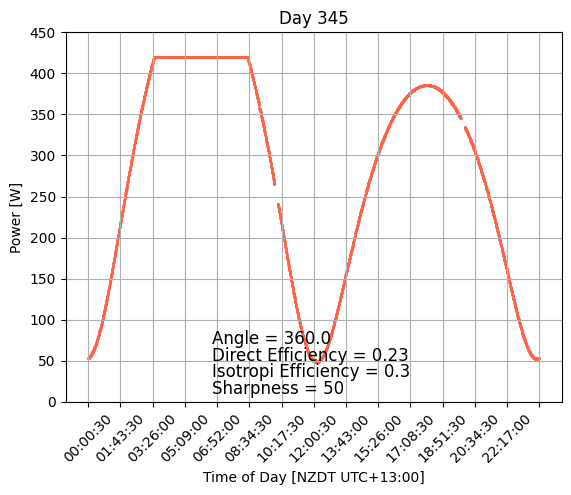

In [582]:
eff_direct = fitted_dir_eff
eff_isotropic = fitted_isotropic_eff
# sharpness = fitted_sharpness

# eff_direct = .22
# eff_isotropic = .08
sharpness = 50



# ax1.scatter(time_101, power_101, label = 'Power_101', s = 1, color = 'brown')
# ax1.scatter(time_101, Fit_Model(np.linspace(0,1440,1440), 0.1, 0.05, 0.08, 50), color = 'tomato', s = 1)
for angle in np.linspace(0,360,10):
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Time of Day [NZDT UTC+13:00]')
    ax1.set_ylabel('Power [W]')
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle),2)[:-1]
    ax1.scatter(time_101, simulation_101, color = 'tomato', s = 1, label = 'simulated Power_101')
    ax1.text(840-50,200+40-170,f'Angle = {np.round(angle,2)}', fontsize = 12)
    
    ax1.text(840-50,260-40-170,f'Direct Efficiency = {np.round(eff_direct, 2)}', fontsize = 12)
    ax1.text(840-50,240-40-170,f'Isotropi Efficiency = {np.round(eff_diffuse, 2)}', fontsize = 12)
    ax1.text(840-50,220-40-170,f'Sharpness = {np.round(sharpness, 2)}', fontsize = 12)
    # ax1.legend(markerscale = 10)
    ax1.set_ylim(0,450)
    ax1.set_xticks(np.linspace(0, len(time_101), 15))
    ax1.set_title(f'Day {day}')
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid('on')
    plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

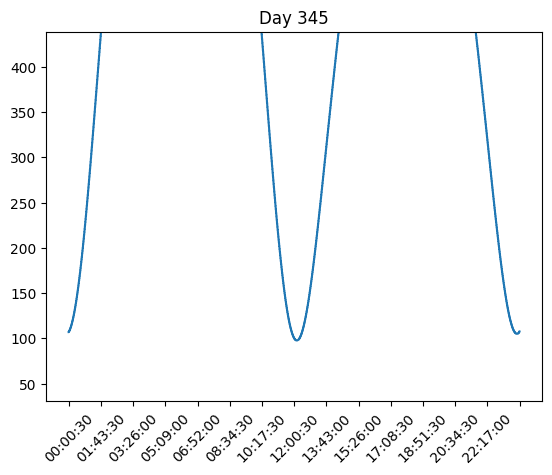

In [588]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

fig, ax = plt.subplots()

simulation_101_0 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, 0),2)[:-1]
x = time_101
line, = ax.plot(x, np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, 0),2)[:-1])
ax.set_xticks(np.linspace(0, len(time_101), 15))
ax.set_title(f'Day {day}')
ax.tick_params(axis='x', labelrotation=45)
angles = np.linspace(0,360,30)
def animate(i):
    # convert i to angle
    angles[i]
    simulation_101 = np.repeat(model(np.linspace(0,1440,1440), Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, [eff_direct, eff_isotropic], sharpness, angle),2)[:-1]
    combined = simulation_101 + simulation_101_0
    line.set_ydata(combined)
    return line,


ani = animation.FuncAnimation(
    fig, animate, interval=20, blit=True, save_count=50)

# To save the animation, use e.g.
#
ani.save("movie.mp4")
#
# or
#
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

plt.show()

In [ ]:
# Entering AI hell

In [364]:
import matplotlib.pyplot as plt
from numpy import exp, linspace, pi, random, sign, sin

from lmfit import create_params, minimize
from lmfit.printfuncs import report_fit

print(type(power_101))
# power_101 = power_101['power_101'].to_numpy(dtype=float)
def Fit_Model(params, time, power_101 = None):
    '''
    wrapping function for model
    '''
    # print(params)
    eff_dir = params['eff_direct']
    eff_isotropic = params['eff_isotropic']
    sharpness = params['sharpness']
    effs = [eff_dir, eff_isotropic]
    sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), [0.2, 0.05, 0.13], 50)
    sim_power_2879 = np.repeat(sim_power, 2)[:-1]
    # print(sim_power)
    valid_mask = ~np.isnan(power_101) & ~np.isnan(sim_power_2879)

    # Subtract only the valid elements
    result = power_101[valid_mask] - sim_power_2879[valid_mask]
    return result

time = np.linspace(0, 2879, 2879)
fit_params = create_params(eff_direct=dict(value=.2, max=1, min=0),
                           eff_isotropic=dict(value=.08, max=1, min = 0),
                           sharpness=dict(value=50, max=200., min=0),
                           )

out = minimize(Fit_Model, fit_params, args=(time,), kws={'power_101': power_101})
# print(fit_params)
fit = Fit_Model(out.params, time, power_101 = power_101)
print(len(fit))
# report_fit(out, modelpars=p_true, correl_mode='table')

<class 'numpy.ndarray'>
2833


ValueError: x and y must have same first dimension, but have shapes (2879,) and (2833,)

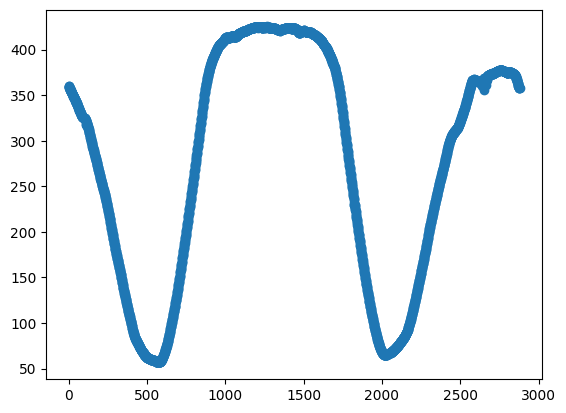

In [363]:
plt.plot(time, power_101, 'o', label='data')
plt.plot(time, fit, label='best fit')
plt.legend()
plt.show()

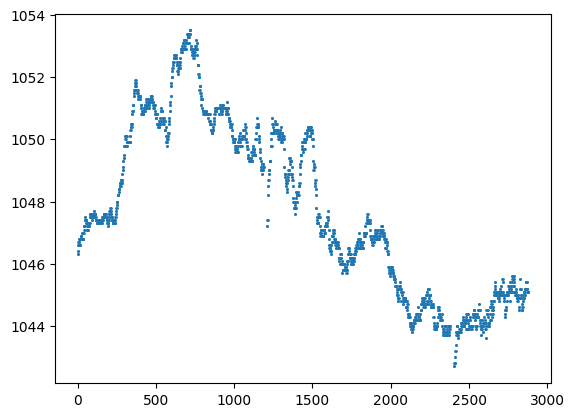

In [373]:
import numpy as np

def fill_nan_with_continuity(arr):
    # Create a copy so we don't modify the original array in place
    arr_filled = arr.copy()
    
    # Create an array of indices (0, 1, 2, ..., n-1)
    indices = np.arange(len(arr_filled))
    
    # Create a boolean mask of where the NaN values are
    nan_mask = np.isnan(arr_filled)
    
    # np.interp(where_we_want_values, where_we_have_indices, where_we_have_values)
    arr_filled[nan_mask] = np.interp(
        indices[nan_mask],     # The indices of the NaNs we want to fill
        indices[~nan_mask],    # The indices of the valid, known numbers
        arr_filled[~nan_mask]  # The actual valid numbers
    )
    
    return arr_filled

# --- Test Case ---
nan = np.nan
array = Direct_Irradiance

result = fill_nan_with_continuity(array)
# plt.scatter(time,np.repeat(result,2)[:-1], s = 1)
plt.scatter(time,np.repeat(Direct_Irradiance,2)[:-1], s = 1)